### TODO: 
-   Solve the timestemp;


# First pipeline for the data preparetion:
Notes: 
- I'm gonna try to save everything in Parquet so pyarrow is need as a new packege
'conda install pyarrow"
```python
conda install pyarrow
```

In [4]:
import pandas as pd
import numpy as np

# - STEP 1 - INGESTION -
# Read CVS files
acc_df = pd.read_csv("Accelerometer.csv")
gyro_df = pd.read_csv("Gyroscope.csv")
grav_df = pd.read_csv("Gravity.csv")
meta_df = pd.read_csv("Metadata.csv")

# Rename columns to avoid conflicts during merging
acc_df = acc_df.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
gyro_df = gyro_df.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})
grav_df = grav_df.rename(columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'})

# - STEP 2 - SYNCHRONIZATION -
epoch_start_ns = meta_df['recording epoch time'].iloc[0] # We save from Metadata the epoch start time in nanoseconds

# Let's convert 'seconds_elapsed' in a proper Datetime Index for each sensor
for df in [acc_df, gyro_df, grav_df]:
    # We use seconds_elapsed to create the precise timestamp
    df['datetime'] = pd.to_datetime(epoch_start_ns, unit='ns') + pd.to_timedelta(df['seconds_elapsed'], unit='s')
    df.set_index('datetime', inplace=True)
    # Remove redundant columns before merging
    df.drop(columns=['time', 'seconds_elapsed'], inplace=True, errors='ignore')


# - STEP 3 - RESAMPLING AND INTERPOLATION (DOWNSAMPLING) ---
target_freq = '10ms'  # 10 milliseconds (100 Hz)

# 1. Merge the three sensor DataFrames on their datetime index
df_merged = pd.concat([acc_df, gyro_df, grav_df], axis=1)

# 2. Resample to a regular temporal grid and interpolate missing values
df_resampled = df_merged.resample(target_freq).mean().interpolate(method='linear')

# Clean up any remaining NaN values at the start or end of the DataFrame
df_resampled = df_resampled.bfill().ffill().reset_index()


# - STEP 4 - SAVE OTHER IMPORTANT INFORMATION -
df_resampled['device_id'] = meta_df['device id'].iloc[0]
df_resampled['device_name'] = meta_df['device name'].iloc[0]

df_resampled['device_id'] = df_resampled['device_id'].astype('category')
df_resampled['device_name'] = df_resampled['device_name'].astype('category')

# Check the data types of the sensor columns and convert them to float32 for memory efficiency
sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z']
df_resampled[sensor_cols] = df_resampled[sensor_cols].astype('float32')

print(df_resampled.head())

                 datetime     acc_z     acc_y     acc_x    gyro_z    gyro_y  \
0 1970-01-01 00:29:49.010  0.292627 -0.391032 -0.265390  0.058143  0.368110   
1 1970-01-01 00:29:49.020  0.410913 -0.451068 -0.252934  0.064154  0.381867   
2 1970-01-01 00:29:49.030  0.565921 -0.478837 -0.229678  0.060914  0.332078   
3 1970-01-01 00:29:49.040  0.753711 -0.463638 -0.193704  0.054013  0.236746   
4 1970-01-01 00:29:49.050  0.724387 -0.480866 -0.197072  0.047553  0.137994   

     gyro_x    grav_z    grav_y    grav_x  \
0  0.199299 -8.584197 -4.740490 -0.098528   
1  0.123731 -8.576636 -4.754675 -0.068937   
2  0.036169 -8.572879 -4.761771 -0.040866   
3 -0.057519 -8.573323 -4.761108 -0.019080   
4 -0.158699 -8.578416 -4.751961 -0.005538   

                              device_id device_name  
0  2902d61d-d820-4893-92f7-4d834be6a862   iPhone 17  
1  2902d61d-d820-4893-92f7-4d834be6a862   iPhone 17  
2  2902d61d-d820-4893-92f7-4d834be6a862   iPhone 17  
3  2902d61d-d820-4893-92f7-4d834be6a86

## Save the processed data in a Parquet file:

In [ ]:
# Save the processed DataFrame to a Parquet file for efficient storage and retrieval
#df_resampled.to_parquet("session_01_processed.parquet", index=False)

## We load the .parquet:
Now we apply a bandpass filter to ours signals for:
-   `lowcut = 5.0` Usefull to cut all the slow nois like padding;
-   `highcut = 30.0` Usefull to cut all the eletric noise;

In [1]:
import pandas as pd
from scipy.signal import butter, filtfilt

#Load the processed DataFrame from the Parquet file
df = pd.read_parquet("session_01_processed.parquet")

fs = 100  # Sampling frequency in Hz

#Apply a bandpass filter to my sensor data to remove high-frequency noise
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band', analog=False)
    y = filtfilt(b, a, data)
    return y    

#Apply the bandpass filter to the accelerometer, gyroscope, and gravity data
lowcut = 5  # Low cutoff frequency in Hz
highcut = 30  # High cutoff frequency in Hz
for col in ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z']:
    df[col] = butter_bandpass_filter(df[col], lowcut, highcut, fs)     
    

In [2]:
def trim_dataframe(df, trim_start_sec=0, trim_end_sec=0, fs=100.0):
    """
    Remove a specified number of seconds from the start and end of a Pandas DataFrame based on the sampling frequency.
    
    Parameters:
    - df: DataFrame di Pandas
    - trim_start_sec: seconds to trim from the start (s)
    - trim_end_sec: seconds to trim from the end (s)
    - fs: Sampling frequency in Hz (Default: 100 Hz)
    
    Returns:
    - Trimmed DataFrame with reset index.
    """
    # Seconds to samples conversion
    start_samples = int(trim_start_sec * fs)
    end_samples = int(trim_end_sec * fs)
    
    # Error handling:
    if start_samples + end_samples >= len(df):
        raise ValueError("The seconds to trim exceed the total duration of the file!")
    
    # Apply the slicing: from the initial samples to the end minus the final samples
    if end_samples > 0:
        df_trimmed = df.iloc[start_samples:-end_samples].copy()
    else:
        df_trimmed = df.iloc[start_samples:].copy()
        
    # Reset the index for convenience
    df_trimmed.reset_index(drop=True, inplace=True)
    
    return df_trimmed

# Trim data to remove the first 3 seconds and the last 2 seconds of the recording
df_trimmed = trim_dataframe(df, trim_start_sec=3.0, trim_end_sec=3.0, fs=100.0)

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_trimmed)}")

Rows before trimming: 1053
Rows after trimming: 453


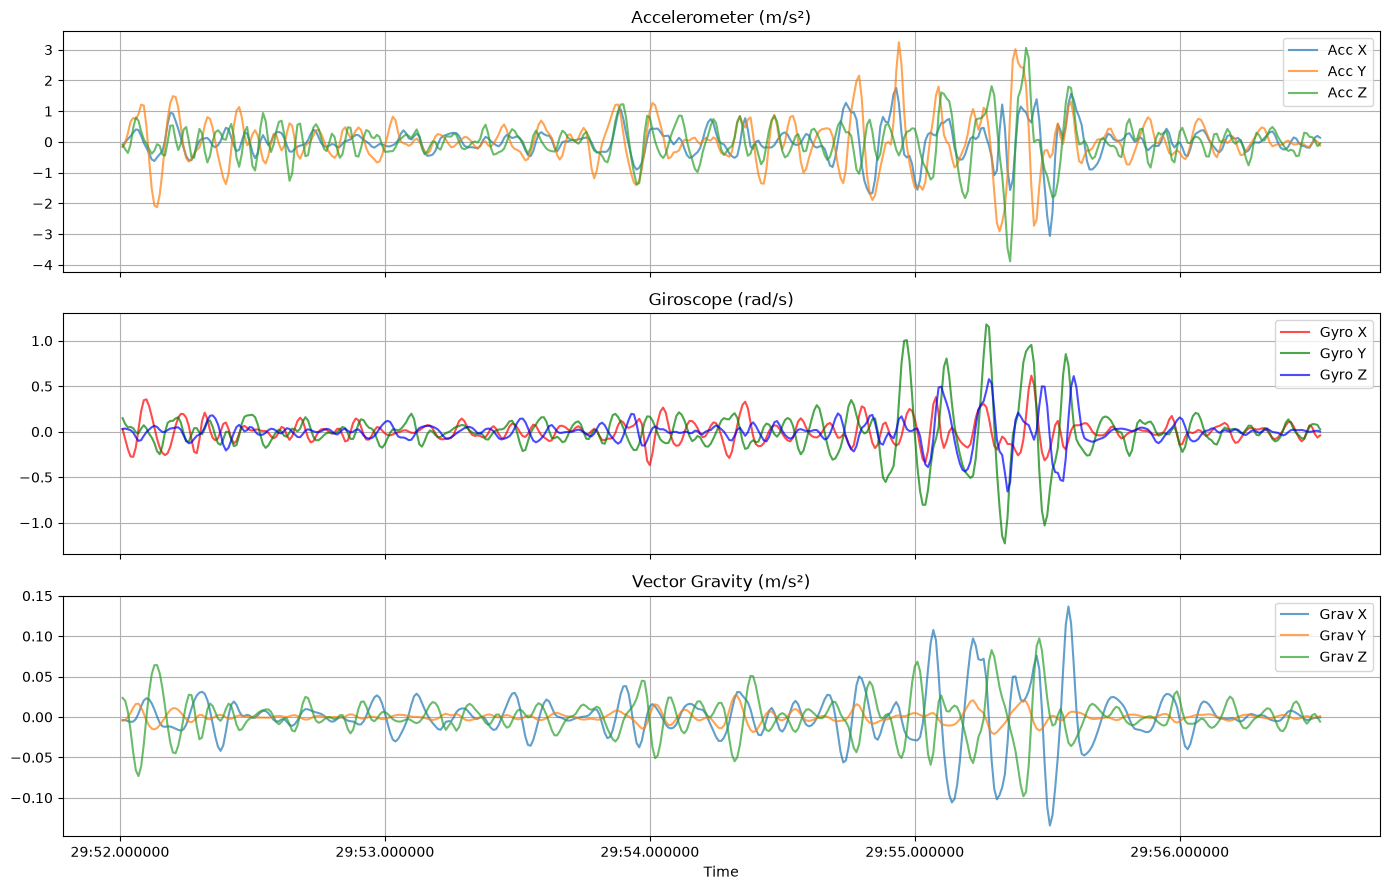

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Accelerometer
axes[0].plot(df_trimmed['datetime'], df_trimmed['acc_x'], label='Acc X', alpha=0.7)
axes[0].plot(df_trimmed['datetime'], df_trimmed['acc_y'], label='Acc Y', alpha=0.7)
axes[0].plot(df_trimmed['datetime'], df_trimmed['acc_z'], label='Acc Z', alpha=0.7)
axes[0].set_title('Accelerometer (m/s²)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Giroscope
axes[1].plot(df_trimmed['datetime'], df_trimmed['gyro_x'], label='Gyro X', alpha=0.7, color='r')
axes[1].plot(df_trimmed['datetime'], df_trimmed['gyro_y'], label='Gyro Y', alpha=0.7, color='g')
axes[1].plot(df_trimmed['datetime'], df_trimmed['gyro_z'], label='Gyro Z', alpha=0.7, color='b')
axes[1].set_title('Giroscope (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Gravity
axes[2].plot(df_trimmed['datetime'], df_trimmed['grav_x'], label='Grav X', alpha=0.7)
axes[2].plot(df_trimmed['datetime'], df_trimmed['grav_y'], label='Grav Y', alpha=0.7)
axes[2].plot(df_trimmed['datetime'], df_trimmed['grav_z'], label='Grav Z', alpha=0.7)
axes[2].set_title('Vector Gravity (m/s²)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()